### **Name : Vishesh Kumar**  
### **CU24250050**  
### **Sec: B**  
### **Roll No : 69**  
### **Computer Vision**  
### **Labsheet - 6**

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

Image loaded successfully


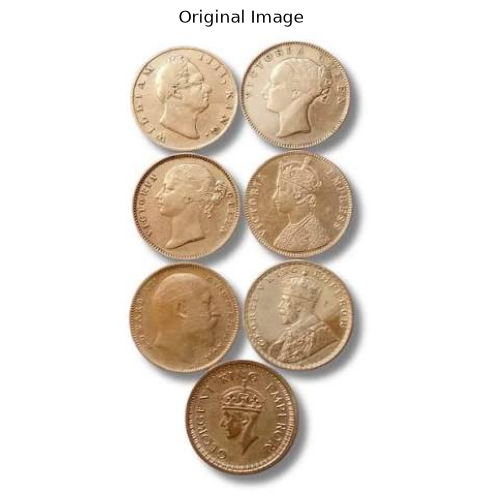

In [3]:
image_path = "coins.jpg"

image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found. Check image path.")
else:
    print("Image loaded successfully")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

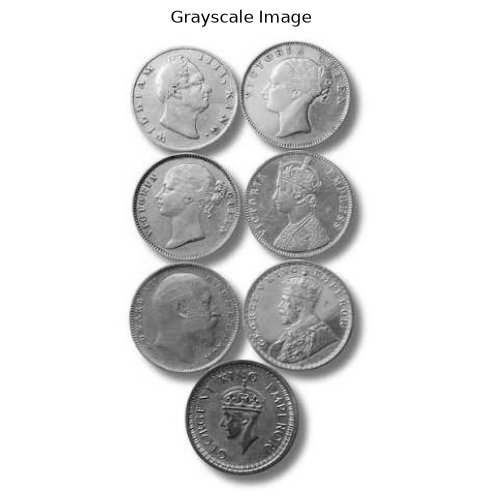

In [4]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

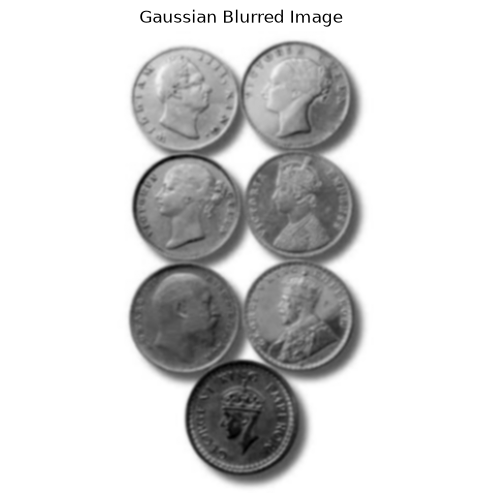

In [5]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(8, 6))
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

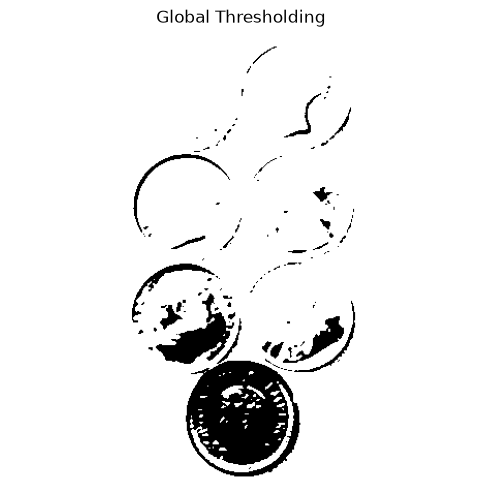

In [6]:
threshold_value = 127

_, global_thresh = cv2.threshold(
    blurred,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(8, 6))
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")
plt.show()

Automatically selected Otsu Threshold: 201.0


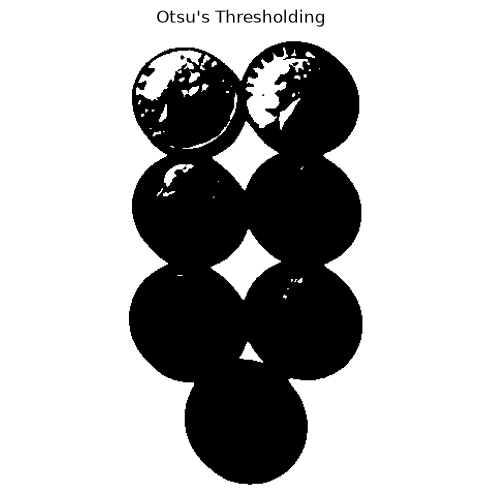

In [7]:
otsu_value, otsu_thresh = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Automatically selected Otsu Threshold:", otsu_value)

plt.figure(figsize=(8, 6))
plt.imshow(otsu_thresh, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")
plt.show()

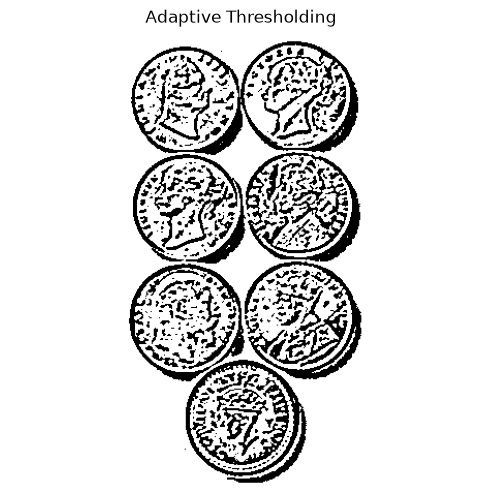

In [8]:
adaptive_thresh = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.figure(figsize=(8, 6))
plt.imshow(adaptive_thresh, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")
plt.show()

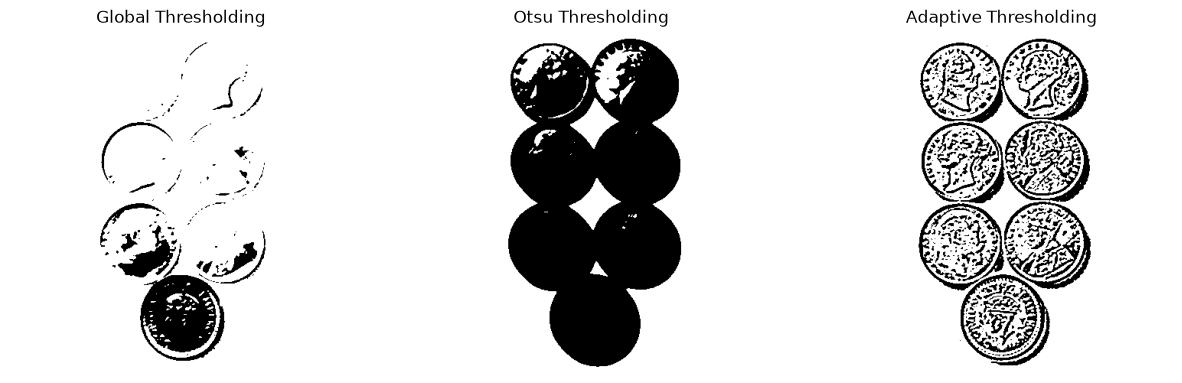

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(otsu_thresh, cmap="gray")
plt.title("Otsu Thresholding")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(adaptive_thresh, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.show()

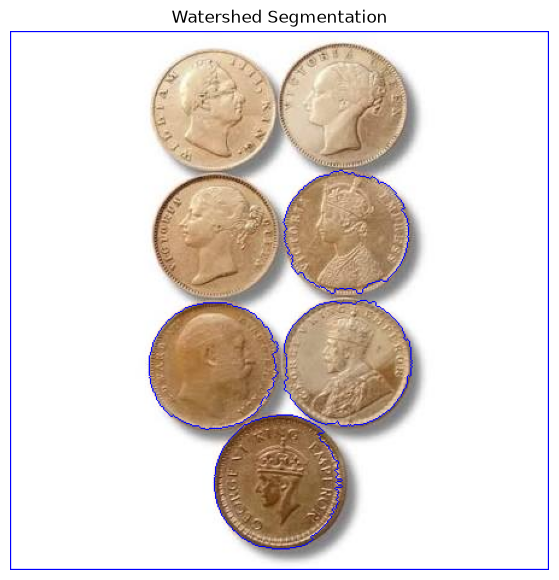

In [10]:
# Binary image
_, binary = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Remove noise
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# Sure background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Distance transform
dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

# Sure foreground
_, sure_fg = cv2.threshold(
    dist_transform,
    0.7 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

# Apply watershed
watershed_image = image.copy()

markers = cv2.watershed(
    watershed_image,
    markers
)

watershed_image[markers == -1] = [255, 0, 0]

watershed_rgb = cv2.cvtColor(
    watershed_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 7))
plt.imshow(watershed_rgb)
plt.title("Watershed Segmentation")
plt.axis("off")
plt.show()

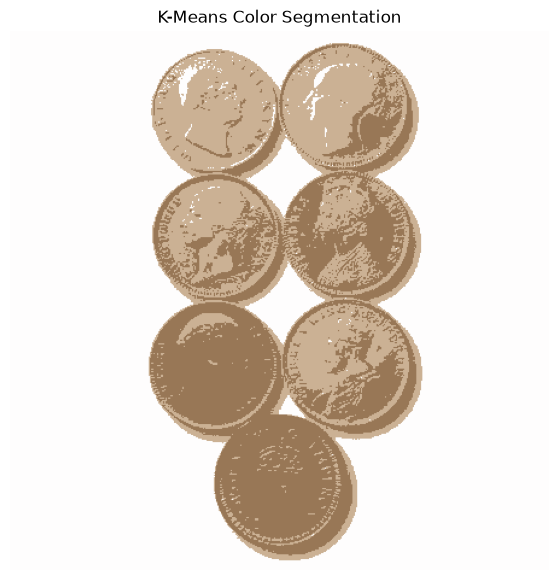

In [11]:
# Convert image from BGR to RGB
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Reshape pixels
pixels = rgb_image.reshape((-1, 3))
pixels = np.float32(pixels)

# Number of clusters
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixels)

# Cluster centers
centers = np.uint8(kmeans.cluster_centers_)

# Replace each pixel with its cluster center
segmented_pixels = centers[labels]

segmented_image = segmented_pixels.reshape(rgb_image.shape)

plt.figure(figsize=(10, 7))
plt.imshow(segmented_image)
plt.title("K-Means Color Segmentation")
plt.axis("off")
plt.show()

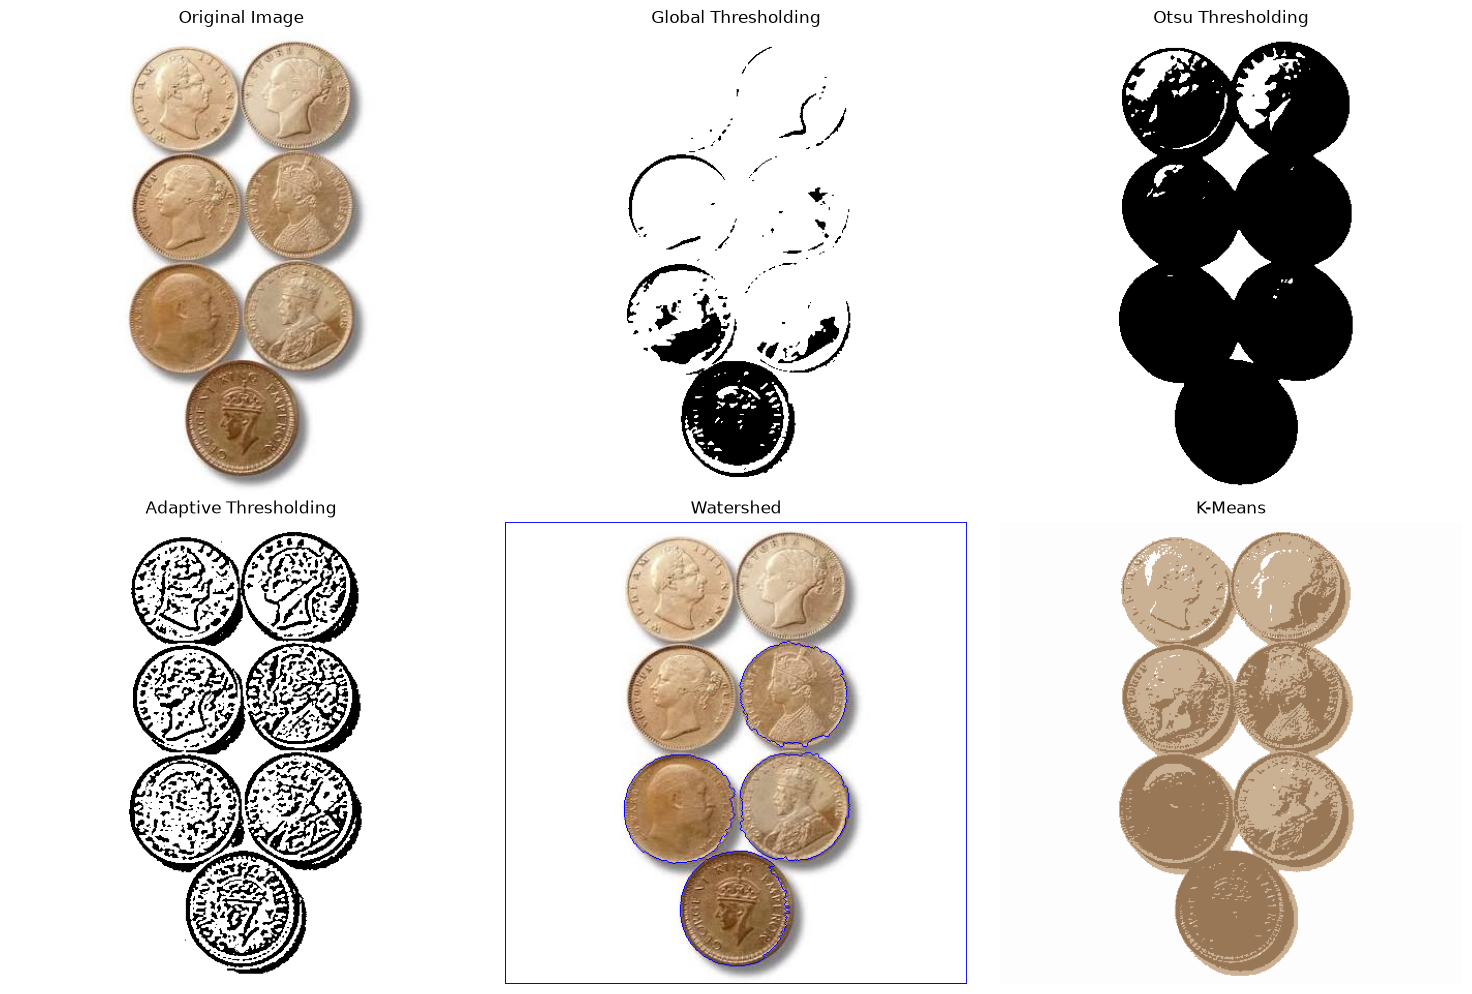

In [12]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(otsu_thresh, cmap="gray")
plt.title("Otsu Thresholding")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(adaptive_thresh, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(watershed_rgb)
plt.title("Watershed")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(segmented_image)
plt.title("K-Means")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
print("SEGMENTATION ANALYSIS")
print("=" * 50)

print("\n1. Global Thresholding:")
print("Simple and fast, but sensitive to illumination changes.")

print("\n2. Otsu's Thresholding:")
print("Automatically selects the threshold and works well for bimodal images.")

print("\n3. Adaptive Thresholding:")
print("Useful when illumination is uneven across the image.")

print("\n4. Watershed:")
print("Useful for separating touching or overlapping objects.")

print("\n5. K-Means:")
print("Useful for color-based segmentation by grouping similar pixels.")

SEGMENTATION ANALYSIS

1. Global Thresholding:
Simple and fast, but sensitive to illumination changes.

2. Otsu's Thresholding:
Automatically selects the threshold and works well for bimodal images.

3. Adaptive Thresholding:
Useful when illumination is uneven across the image.

4. Watershed:
Useful for separating touching or overlapping objects.

5. K-Means:
Useful for color-based segmentation by grouping similar pixels.


In [14]:
print("FINAL OBSERVATION")
print("=" * 50)

print("""
Image segmentation divides an image into meaningful regions.

Global Thresholding is simple and computationally efficient.
Otsu's method automatically finds a suitable threshold.
Adaptive Thresholding performs better under uneven illumination.
Watershed is useful for separating touching objects.
K-Means is useful for color-based image segmentation.

The most suitable technique depends on the image characteristics,
background complexity, illumination, and segmentation requirements.
""")

FINAL OBSERVATION

Image segmentation divides an image into meaningful regions.

Global Thresholding is simple and computationally efficient.
Otsu's method automatically finds a suitable threshold.
Adaptive Thresholding performs better under uneven illumination.
Watershed is useful for separating touching objects.
K-Means is useful for color-based image segmentation.

The most suitable technique depends on the image characteristics,
background complexity, illumination, and segmentation requirements.

